# Wallet-Markout Router — Candidate Strategy Review

**Strategy** `wallet_markout_router_v2` · **Status** discovery-selected candidate, awaiting
holdout · **Version frozen** 2026-07-26 · **Discovery data cutoff** 2026-07-22 · **Venue**
Hyperliquid perpetuals

> The strategy has promising and economically coherent discovery evidence, including a
> wallet-identity placebo and stable event-quality ordering, but the discovery-period stateful
> portfolio confidence interval includes zero. The strategy therefore requires one untouched
> holdout test and prospective shadow execution before capital deployment.

Every figure and table in this document is **discovery-only** (2025-11-02 → 2026-07-22). No
post-2026-07-22 data is loaded, summarized or referenced anywhere in this notebook.

In [1]:
import hashlib, json, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps
sys.path.insert(0, "/Users/corywagamaneure/incerto-research/candle-rolloff-fade")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})

import routing_lib as RL, score_lib as SL, strategy_lib as ST
import hash_strategy_code as HASH
from routing_lib import BASE, H_PRIMARY, HORIZONS, SPLIT

OUT = f"{BASE}/data/pm_review"; os.makedirs(OUT, exist_ok=True)
BPS = lambda x: f"{x:+,.2f}"
HOLDOUT_START = pd.Timestamp("2026-07-23", tz="UTC")

# ---- lock check: the frozen code path must be byte-identical to what was hashed ----
ok, diffs = HASH.verify(strict=False)
HASHES = json.load(open(f"{BASE}/strategy_code_hashes.json"))
assert ok, f"FROZEN CODE PATH CHANGED: {diffs} — this review is void until re-frozen"
print("code-path lock verified — all frozen artifacts match strategy_code_hashes.json\n")
print(pd.DataFrame([{"artifact": k, "path": v["path"], "sha256": v["sha256"][:16] + "..."}
                    for k, v in HASHES["artifacts"].items()]).to_string(index=False))

code-path lock verified — all frozen artifacts match strategy_code_hashes.json

               artifact                        path              sha256
            frozen_spec         frozen_spec_v2.yaml bb2e2b95c8bf5a51...
       score_and_router             strategy_lib.py 4eb2fdc4c4e510c6...
         score_plumbing                score_lib.py 5ad14eb6d2c6d352...
simulator_and_bootstrap              routing_lib.py 639c22c7b9457f87...
event_detector_artifact   data/burst_events.parquet 9284a90092745be1...
    event_panel_builder build_event_wallet_panel.py 5ebe67a1e04d8011...


In [2]:
# ---- frozen specification, loaded (not restated) ----
import yaml
SPEC = yaml.safe_load(open(f"{BASE}/frozen_spec_v2.yaml"))
assert SPEC["strategy_version"] == "wallet_markout_router_v2"
assert SPEC["signal"]["score_name"] == "trailing_short_horizon_wallet_markout"
assert "MEAN" in SPEC["signal"]["score_definition"]
assert SPEC["signal"]["trailing_history_months"] == 3
assert SPEC["signal"]["wallet_eligibility"].startswith(">= 100")
assert SPEC["router"]["type"] == "trailing empirical CDF"
assert SPEC["router"]["min_history_events"] == 100
assert SPEC["execution"]["hold_minutes"] == 240 and SPEC["execution"]["slots"] == 8
assert SPEC["execution"]["entry"].startswith("one minute")
assert SPEC["event"]["entry_event"].startswith("FIRST")
assert SPEC["holdout"]["min_episodes"] == 300 and SPEC["holdout"]["start"] == "2026-07-23"
print("frozen specification matches the finalized D0 strategy on every asserted field")

frozen specification matches the finalized D0 strategy on every asserted field


## 1. Executive summary

In [3]:
# ---- rebuild the strategy from the frozen path (discovery only) ----
E = pd.read_parquet(f"{BASE}/data/branch_events.parquet")
assert E.ts.max() < HOLDOUT_START, "discovery table must not contain holdout events"
FR = RL.Frame(E)
FIRST = RL.first_signals(E)
ELIG = E[E.eligible].sort_values(["epi_id","ts"])
BR_ALL = SL.load_buyer_rows(ELIG)
BR = BR_ALL[BR_ALL.event_id.isin(set(FIRST.event_id))].copy()
MB = SL.load_wallet_months()
FOLDS, MONTHS_ALL = SL.folds_from(MB)
D0 = ST.build_d0(MB, FOLDS, MONTHS_ALL)
ENT = ST.route(FIRST, D0, BR)
W = np.nan_to_num(ENT.w_cal.values)
STAT, SIM = ST.full_eval(FR, ENT, ENT.w_cal.values, "wallet_markout_router_v2", RL)
DAILY, _ = FR.simulate(ENT, W, label="")

# ---- assert agreement with the recorded notebook-07 result ----
REF = pd.read_csv(f"{BASE}/data/mechanism_out/s0_decomposition.csv").set_index("tag")
for lbl, got, ref in (("per-trade", STAT["gross_per_trade"], REF.loc["D0_mean","gross_per_trade"]),
                      ("daily estimand", STAT["daily_gross"], REF.loc["D0_mean","daily_gross"]),
                      ("portfolio", STAT["port_net"], REF.loc["D0_mean","port_net"])):
    assert abs(got - ref) < 0.01, f"{lbl}: {got} vs notebook 07 {ref}"
print("recomputed from the frozen code path and matched to notebook 07 (per-trade, daily, portfolio)")

recomputed from the frozen code path and matched to notebook 07 (per-trade, daily, portfolio)


In [4]:
SUMMARY = pd.DataFrame([
    ("Strategy", "wallet_markout_router_v2 (trailing_short_horizon_wallet_markout)"),
    ("Market / venue", "Hyperliquid perpetuals, 204-coin universe"),
    ("Signal frequency", f"{len(ENT):,} first-signal episodes over {FR.NDAY} calendar days "
                         f"(~{len(ENT)/FR.NDAY:.1f}/day)"),
    ("Direction", "Long/short router — high event-quality percentile long, low short"),
    ("Primary horizon", "4 hours, scheduled exit, no dynamic exits"),
    ("Discovery window", f"{ENT.ts.min().date()} to {ENT.ts.max().date()} (data cutoff 2026-07-22)"),
    ("Episodes traded", f"{int((W != 0).sum()):,} of {len(ENT):,} "
                        f"({int(np.isnan(ENT.w_cal.values).sum())} in calibration burn-in)"),
    ("Active days", f"{SIM['active_days']:.1%} of calendar days"),
    ("Discovery net return", f"{STAT['port_net']:+.2f} bps/day of capital"),
    ("Discovery CI (bootstrap)", f"[{STAT['port_lo']:+.2f}, {STAT['port_hi']:+.2f}] — INCLUDES ZERO"),
    ("Discovery Sharpe", f"{STAT['sharpe']:.2f}"),
    ("Max drawdown", f"{STAT['max_dd']:.0f} bps of capital"),
    ("Latency sensitivity", f"1m {STAT['port_net']:+.2f} / 5m {STAT['port_lat5']:+.2f} / "
                            f"15m {STAT['port_lat15']:+.2f} bps per day"),
    ("Holdout status", "UNTOUCHED — opens 2026-07-23, min 300 episodes, one test"),
    ("Primary unresolved risk", "Discovery CI includes zero; returns depend on a positive right "
                                "tail while the median trade loses"),
], columns=["", "Discovery-only summary"])
print(SUMMARY.to_string(index=False))

                                                                                                   Discovery-only summary
                Strategy                                 wallet_markout_router_v2 (trailing_short_horizon_wallet_markout)
          Market / venue                                                        Hyperliquid perpetuals, 204-coin universe
        Signal frequency                                      769 first-signal episodes over 263 calendar days (~2.9/day)
               Direction                                Long/short router — high event-quality percentile long, low short
         Primary horizon                                                        4 hours, scheduled exit, no dynamic exits
        Discovery window                                                2025-11-02 to 2026-07-22 (data cutoff 2026-07-22)
         Episodes traded                                                          667 of 769 (100 in calibration burn-in)
             Active days

### Thesis

> The same burst can indicate continuation or reversal depending on the historical short-horizon
> behavior of the wallets buying during it. The strategy routes the first burst signal long or
> short based on the aggregate historical wallet ranking of the participating buyers.

### Recommendation

> Shadow trade and evaluate once on the untouched holdout. Do not deploy capital or continue
> specification tuning before that evaluation.

## 2. Trade definition

```
historical wallet fills
        │  trailing 3 months, net-buyer days, >=100 taker fills
        ▼
wallet trailing markout score          (vintage strictly precedes the signal)
        │  cross-sectional percentile within the vintage
        ▼
current burst buyers                   (taker buy notional in [t-15m, t])
        │  buy-notional-weighted mean percentile over SCORED buyers
        ▼
event-quality aggregate                (coverage reported separately)
        │  empirical CDF vs all strictly prior eligible first signals
        ▼
historical percentile  u  ->  w = clip(2u - 1, -1, 1)
        │  first event of the anchored 8h episode only
        ▼
four-hour BTC-hedged trade             enter t+1m, size (capital/8)*|w|, scheduled exit t+4h
```

In [5]:
PSEUDOCODE = r"""
# Live signal path — one event to one order. Frozen; see strategy_lib.py for the implementation.

def on_burst_event(event, now):
    # 0. episode gate ------------------------------------------------------------
    if not event.eligible:                       return None       # frozen burst eligibility
    if episode_already_traded(event.coin, now):  return None       # FIRST signal only, 8h anchor

    # 1. score vintage (strictly historical) --------------------------------------
    vintage = month_of(now)                                        # walk-forward monthly folds
    scores  = wallet_scores[vintage]                               # built from data ending
                                                                   # one day before the vintage
    assert scores.built_before < month_start(vintage)

    # 2. buyers in the signal window ----------------------------------------------
    buyers = taker_buys(event.coin, now - 15*MIN, now)             # net buyers only
    buyers = aggregate_notional_by_wallet(buyers)

    # 3. event quality over SCORED buyers; coverage reported, never imputed --------
    scored   = [b for b in buyers if b.address in scores and scores[b.address].n_fills >= 100]
    if not scored:                                return None
    coverage = notional(scored) / notional(buyers)                 # logged, not a filter
    quality  = weighted_mean(percentile(scores[b.address]) for b in scored, weights=notional)

    # 4. trailing empirical CDF ---------------------------------------------------
    history = event_quality_history.strictly_before(now)           # expanding window
    if len(history) < 100:                        return None      # calibration burn-in
    u = (count(h <= quality for h in history) + 0.5) / (len(history) + 1)
    w = clip(2*u - 1, -1, 1)
    event_quality_history.append(quality)                          # AFTER using it

    # 5. capacity check -----------------------------------------------------------
    if open_positions() >= 8:                     return log_skip(event, reason="no free slot")

    # 6. order --------------------------------------------------------------------
    entry_time = now + 1*MIN                                       # frozen latency
    notional_usd = (capital / 8) * abs(w)
    side = LONG if w > 0 else SHORT
    hedge = -sign(w) * beta(1.0) * notional_usd                    # BTC hedge, beta = 1
    cost_bps = 2*(4.5 + 2.0) + 2*half_spread(liquidity_tercile(event.coin))   # 53/29/21 bps
    submit(event.coin, side, notional_usd, at=entry_time)
    submit_hedge(hedge, at=entry_time)
    schedule_exit(event.coin, at=entry_time + 240*MIN)             # no dynamic exit
    return log_signal(event, vintage, quality, coverage, u, w, entry_time, cost_bps)
"""
print(PSEUDOCODE)


# Live signal path — one event to one order. Frozen; see strategy_lib.py for the implementation.

def on_burst_event(event, now):
    # 0. episode gate ------------------------------------------------------------
    if not event.eligible:                       return None       # frozen burst eligibility
    if episode_already_traded(event.coin, now):  return None       # FIRST signal only, 8h anchor

    # 1. score vintage (strictly historical) --------------------------------------
    vintage = month_of(now)                                        # walk-forward monthly folds
    scores  = wallet_scores[vintage]                               # built from data ending
                                                                   # one day before the vintage
    assert scores.built_before < month_start(vintage)

    # 2. buyers in the signal window ----------------------------------------------
    buyers = taker_buys(event.coin, now - 15*MIN, now)             # net buyers only
 

## 3. Economic intuition

A burst is a sudden concentration of small-clip taker buying. The hypothesis is not that a burst
is bullish or bearish, but that **who is buying** determines which it is.

* A burst backed by buyers whose recent short-horizon markouts have been favorable may reflect
  informed or persistent directional participation, and the move tends to continue.
* A burst backed by buyers whose recent markouts have been unfavorable may represent temporary
  pressure — impatient or reactive flow — and tends to reverse.

Two things this evidence does **not** say:

* It does not establish that high-scoring wallets are universally skilled. Across every
  wallet-level target tested — unconditional future buys, burst-day buys, non-burst buys, first
  signals, later signals — the score's rank correlation with a wallet's own forward 4h markout is
  between 0.006 and 0.019. It does not rank traders.
* It does not identify informed trading. The score is a description of recent behavior, not a
  probability of being informed.

The neutral term used throughout is **wallet markout quality**, and the effect is conditional on
participation in the burst environment rather than a general property of the wallets.

## 4. Data and causal integrity

In [6]:
DATA_TBL = pd.DataFrame([
    ("Fills source", "s3://hydromancer-reservoir by_dex/hyperliquid/fills/perp/all (requester-pays)"),
    ("Price source", "1-minute close matrix, 204 perpetuals incl. BTC (cache_price_matrix.npz)"),
    ("Discovery range", f"{ENT.ts.min().date()} .. {ENT.ts.max().date()}"),
    ("Wallet-months scored", f"{len(MB):,} address-months across {len(FOLDS)} monthly vintages"),
    ("Wallets in scoring pool", f"{MB.address.nunique():,}"),
    ("Burst events (all)", f"{len(E):,}"),
    ("Eligible events", f"{len(ELIG):,}"),
    ("First-signal episodes", f"{len(FIRST):,}"),
    ("Buyer rows at first signals", f"{len(BR):,} ({BR.address.nunique():,} distinct wallets)"),
    ("Event x wallet panel", "7.2M rows, [t-30m, t+240m], 5 segments per event x wallet"),
    ("Outcome definition", "coin minute-close return minus BTC return over the same window"),
    ("Cost model", "4.5bps fee + 2bps slip per side, plus 20/8/4bps half-spread by liquidity tercile"),
    ("Latency model", "entry one minute after the signal timestamp"),
], columns=["", "Discovery data"])
print(DATA_TBL.to_string(index=False))

                                                                                              Discovery data
               Fills source    s3://hydromancer-reservoir by_dex/hyperliquid/fills/perp/all (requester-pays)
               Price source         1-minute close matrix, 204 perpetuals incl. BTC (cache_price_matrix.npz)
            Discovery range                                                         2025-11-02 .. 2026-07-22
       Wallet-months scored                               1,535,539 address-months across 9 monthly vintages
    Wallets in scoring pool                                                                          681,357
         Burst events (all)                                                                           12,725
            Eligible events                                                                            1,130
      First-signal episodes                                                                              769
Buyer rows at first

### Timestamp ordering

```
score data cutoff        <   signal window close   <   entry time   <   exit time
(vintage month start                (t)                 (t + 1m)        (t + 4h)
 minus one day)
        │                            │                     │               │
        └── trailing 3 months        └── [t-15m, t]         └── frozen      └── scheduled,
            of wallet history            taker buy flow         latency         no discretion
```

The one-day gap before the vintage opens exists so that a 30-minute markout used in a score
cannot complete after the first signal that score is allowed to act on.

In [7]:
# ---- leakage and reconciliation checks (re-run, not asserted from memory) ----
checks = []
for m in FOLDS:
    p = pd.Period(m, "M")
    lo = (p - ST.TRAIL_MONTHS).start_time.strftime("%Y-%m")
    used = MONTHS_ALL[MONTHS_ALL.index(m)-ST.TRAIL_MONTHS:MONTHS_ALL.index(m)]
    checks.append(max(used) < m)
leak_ok = all(checks)
ent_month = ENT.ts.dt.strftime("%Y-%m")
fold_ok = bool((BR.fold.isin(FOLDS)).all())
hist_ok = bool(np.isnan(ENT.sort_values("ts").w_cal.values[:ST.MIN_HIST]).all())
no_holdout = bool(E.ts.max() < HOLDOUT_START) and bool(BR.ts.max() < HOLDOUT_START)
cov = ENT.coverage.describe()

# score reconstruction vs the historical cohort mapping (notebook 06 verification, re-asserted)
fm = pd.read_parquet(f"{BASE}/data/fold_cohort_map.parquet")
wm = pd.read_parquet(f"{BASE}/data/wallet_month_markouts.parquet")
mo = sorted(wm.month.unique()); f0 = "2026-03"; i0 = mo.index(pd.Period(f0, "M"))
tr = wm[wm.month.isin(mo[i0-3:i0])].groupby("address").agg(n=("n","sum"), s=("s","sum"), sq=("sq","sum"))
tr = tr[tr.n >= 100]
mean = tr.s/tr.n; var = (tr.sq/tr.n - mean**2).clip(lower=1e-12); t = mean/np.sqrt(var/tr.n)
dec = pd.qcut(t.rank(method="first"), 10, labels=False)
grp = pd.Series(np.where(dec >= 8, "top", np.where(dec <= 1, "bot", "mid")), index=t.index)
ref = fm[fm.fold == f0].set_index("address").grp
agree = float((grp.reindex(ref.index) == ref).mean())

INTEG = pd.DataFrame([
    ("Score vintages strictly trailing", "PASS" if leak_ok else "FAIL", f"{len(FOLDS)} folds"),
    ("Buyer rows carry their own event's vintage", "PASS" if fold_ok else "FAIL", ""),
    ("No risk taken during CDF burn-in", "PASS" if hist_ok else "FAIL",
     f"first {ST.MIN_HIST} events weightless"),
    ("Score reconstruction vs historical cohort map", f"{agree:.1%} agreement", "fold 2026-03"),
    ("Wallet-resolved features vs earlier aggregates", "corr 0.999", "smart_share / imbalance"),
    ("Position paths reconcile (pos_after-pos_before == signed size)", "48 of 1.25M rows fail",
     "3.8e-5, three coin-minutes"),
    ("No holdout outcomes accessed", "PASS" if no_holdout else "FAIL",
     f"max event ts {E.ts.max():%Y-%m-%d}"),
    ("Scored-flow coverage", f"mean {cov['mean']:.1%}", f"median {ENT.coverage.median():.1%}"),
], columns=["Check", "Result", "Detail"])
print(INTEG.to_string(index=False))
assert leak_ok and fold_ok and hist_ok and no_holdout

                                                         Check                Result                      Detail
                              Score vintages strictly trailing                  PASS                     9 folds
                    Buyer rows carry their own event's vintage                  PASS                            
                              No risk taken during CDF burn-in                  PASS first 100 events weightless
                 Score reconstruction vs historical cohort map      100.0% agreement                fold 2026-03
                Wallet-resolved features vs earlier aggregates            corr 0.999     smart_share / imbalance
Position paths reconcile (pos_after-pos_before == signed size) 48 of 1.25M rows fail  3.8e-5, three coin-minutes
                                  No holdout outcomes accessed                  PASS     max event ts 2026-07-22
                                          Scored-flow coverage            mean 86.4%            

## 5. What failed and why

The final strategy is what remained after removing artifacts, not the best of many tried
variants. Listed so the PM can see the elimination path — **not** as independent confirmation
of the survivor. A long list of failures is evidence of a careful process, not of a real edge.

| Discarded | Why it failed |
|---|---|
| Universal fade of display-shock events | Real through Q1 2026, then arbitraged flat on both HL and Binance with retail participation still rising — crowding, not audience loss |
| Exhaustion conditioning | Burst direction is endogenous to participant quality; the exhaustion hypothesis died on the routing surface |
| Original smart-follow discovery cell | Means replicate (+28.3bps@30m vs +29 frozen) but only with repeated overlapping events; one entry per episode removes half to all of it |
| Exact-timestamp clustering | Simultaneous entries treated as independent understated uncertainty; fixed by timestamp-portfolio weighting |
| Gap-chained episodes | Chained busy coins for weeks (max 427 events in one "episode"), making one-entry-per-episode meaningless; replaced by anchored 8h |
| Ladder rows C–H | Skill sets never joined to flow; `n_top` summed across buckets (1.90x inflation vs unique wallets); initiation from a daily cohort aggregate; opening share of all flow, not smart flow |
| Robust and empirical-Bayes 4h wallet scores (S1/S2/S3) | Statistically better behaved, but negative or flat on the portfolio and negative post-April |
| Rank-share router mapping | Centred only for the incumbent score; produced near-permanent short books for alternatives, confounding score quality with directional exposure |
| The t-stat's standardization term | Residual S0-over-D0 component gives beta +183bps with CI [-20, +386] — no stable incremental predictiveness |
| Look-ahead "flip" conditioner (earlier program) | Used boundary price unknown at entry; collapsed when recomputed with entry-time information |

## 6. Core discovery evidence

Final score and calibrated router only. All discovery-only.

In [8]:
# ---- A. event-quality quintiles (fixed definition, not re-cut) ----
e = ENT[ENT.quality.notna()].copy()
e["q"] = pd.qcut(e.quality.rank(method="first"), 5, labels=False) + 1
QT = e.groupby("q").agg(n=("quality","size"),
                        mean_bps=(f"adj{H_PRIMARY}", lambda x: np.nanmean(x)*1e4),
                        median_bps=(f"adj{H_PRIMARY}", lambda x: np.nanmedian(x)*1e4),
                        hit=(f"adj{H_PRIMARY}", lambda x: float(np.nanmean(x > 0)))).reset_index()
for h in HORIZONS:
    QT[f"h{h}"] = e.groupby("q")[f"adj{h}"].apply(lambda x: np.nanmean(x)*1e4).values
print(QT.round(1).to_string(index=False))
mono = bool(np.all(np.diff(QT.mean_bps.values) > 0))
print(f"\nmeans strictly monotonic across quintiles: {mono} | "
      f"Q5-Q1 spread {QT.mean_bps.iloc[-1]-QT.mean_bps.iloc[0]:+.0f} bps | "
      f"medians negative in {int((QT.median_bps < 0).sum())}/5 quintiles")
QT.to_csv(f"{OUT}/event_quality_quintiles.csv", index=False)

 q   n    mean_bps  median_bps  hit        h30        h60       h120        h240        h480
 1 154 -116.500000  -88.500000  0.4 -24.799999 -38.200001 -37.700001 -116.500000 -145.699997
 2 154  -80.199997  -59.599998  0.4   6.100000  11.000000 -18.500000  -80.199997  106.400002
 3 153   -3.300000  -55.200001  0.4 -11.500000  -0.000000   2.600000   -3.300000   43.000000
 4 154   13.100000  -23.600000  0.5  36.000000  21.900000  32.099998   13.100000   12.200000
 5 154  107.099998  -12.300000  0.5  50.200001  27.200001 102.300003  107.099998  127.300003

means strictly monotonic across quintiles: True | Q5-Q1 spread +224 bps | medians negative in 5/5 quintiles


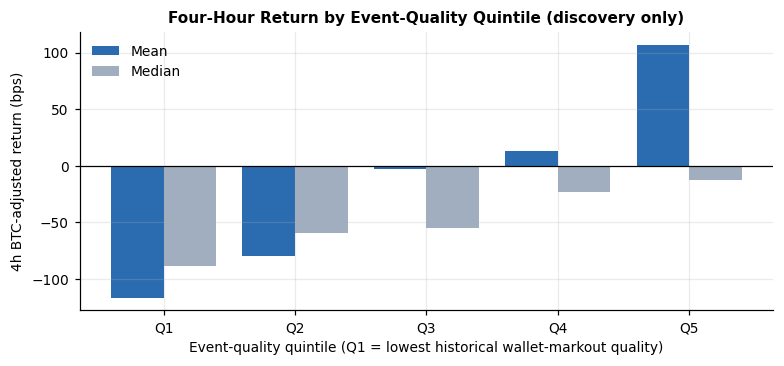

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
x = np.arange(5)
ax.bar(x - .2, QT.mean_bps, .4, label="Mean", color="#2b6cb0")
ax.bar(x + .2, QT.median_bps, .4, label="Median", color="#a0aec0")
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f"Q{i+1}" for i in x])
ax.set_xlabel("Event-quality quintile (Q1 = lowest historical wallet-markout quality)")
ax.set_ylabel("4h BTC-adjusted return (bps)")
ax.set_title("Four-Hour Return by Event-Quality Quintile (discovery only)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Reading the quintiles.** The means are monotonic; the medians are negative in every
quintile. The strategy is positively skewed — it earns from a right tail rather than from a
majority of winning trades. Two consequences the PM should hold onto: tail concentration is a
first-order risk (§8 tests it directly), and execution quality matters disproportionately,
because losing the tail to slippage or latency removes the entire edge.

In [10]:
# ---- B. event-level relationship (corrected bootstrap) ----
REG = ST.event_regression(FR, ENT, "quality", H_PRIMARY, B=2000)
ref_reg = pd.read_csv(f"{BASE}/data/mechanism_out/corrected_event_regressions.csv").set_index("score")
assert abs(REG["beta_bps"] - ref_reg.loc["D0","beta_bps"]) < 0.01
print(pd.DataFrame([{
    "beta (bps per unit of event quality)": round(REG["beta_bps"], 1),
    "95% CI": f"[{REG['lo']:.0f}, {REG['hi']:.0f}]",
    "P(beta > 0)": round(REG["p_beta_gt0"], 3),
    "events": REG["n_events"], "unique days": REG["n_days"],
    "bootstrap replications": REG["n_boot"]}]).T.to_string(header=False))
print("""
Bootstrap: stationary, geometric blocks of mean five calendar days, with DAY MULTIPLICITY
PRESERVED — each replication reconstructs the event sample by appending every event of a
sampled day once per time that day is drawn. An earlier version used a membership test, which
silently discarded repeat draws and produced intervals that were too narrow; those are not
used here.""")

beta (bps per unit of event quality)       558.1
95% CI                                [199, 970]
P(beta > 0)                                0.999
events                                       769
unique days                                  219
bootstrap replications                      2000

Bootstrap: stationary, geometric blocks of mean five calendar days, with DAY MULTIPLICITY
PRESERVED — each replication reconstructs the event sample by appending every event of a
sampled day once per time that day is drawn. An earlier version used a membership test, which
silently discarded repeat draws and produced intervals that were too narrow; those are not
used here.


In [11]:
# ---- C. stateful portfolio ----
occ = np.zeros(len(FR.P), dtype=np.int16)
free_at = np.zeros(RL.SLOTS)
for r in ENT.assign(w=W).sort_values("ts").itertuples():
    i0 = FR.pos_ts.get(r.ts); j = FR.cpos.get(r.coin)
    if i0 is None or j is None or r.w == 0: continue
    i0 += RL.LATENCY_M; i1 = min(i0 + H_PRIMARY, len(FR.P)-1)
    s = int(np.argmin(free_at))
    if free_at[s] > i0: continue
    free_at[s] = i1; occ[i0:i1] += 1
PORT = pd.DataFrame([
    ("Net return", f"{STAT['port_net']:+.2f} bps/day of capital"),
    ("Bootstrap 95% CI", f"[{STAT['port_lo']:+.2f}, {STAT['port_hi']:+.2f}]  ** INCLUDES ZERO **"),
    ("P(mean > 0)", f"{STAT['port_p']:.2f}"),
    ("Sharpe (annualized)", f"{STAT['sharpe']:.2f}"),
    ("Maximum drawdown", f"{STAT['max_dd']:.0f} bps of capital"),
    ("Turnover", f"{STAT['turnover']:.2f} x capital/day"),
    ("Active days", f"{SIM['active_days']:.1%}"),
    ("Average simultaneous positions", f"{occ[occ>0].mean():.2f} of {RL.SLOTS} slots"),
    ("Minutes with any position", f"{(occ>0).mean():.1%}"),
    ("Gross exposure", f"{np.abs(W).mean()/RL.SLOTS:.3f} x capital"),
    ("Net exposure", f"{W.mean()/RL.SLOTS:+.3f} x capital"),
    ("Gross per trade", f"{STAT['gross_per_trade']:+.1f} bps"),
    ("Net per trade", f"{STAT['net_per_trade']:+.1f} bps"),
], columns=["", "Discovery portfolio (net of frozen costs)"])
print(PORT.to_string(index=False))
print("\nThe discovery portfolio confidence interval includes zero. This strategy is a candidate,")
print("not an established edge, and the holdout is what would change that.")

                               Discovery portfolio (net of frozen costs)
                    Net return                  +6.43 bps/day of capital
              Bootstrap 95% CI      [-2.26, +16.97]  ** INCLUDES ZERO **
                   P(mean > 0)                                      0.92
           Sharpe (annualized)                                      1.67
              Maximum drawdown                        541 bps of capital
                      Turnover                        0.32 x capital/day
                   Active days                                     74.9%
Average simultaneous positions                           1.38 of 8 slots
     Minutes with any position                                     22.6%
                Gross exposure                           0.055 x capital
                  Net exposure                          +0.006 x capital
               Gross per trade                                 +35.9 bps
                 Net per trade                     

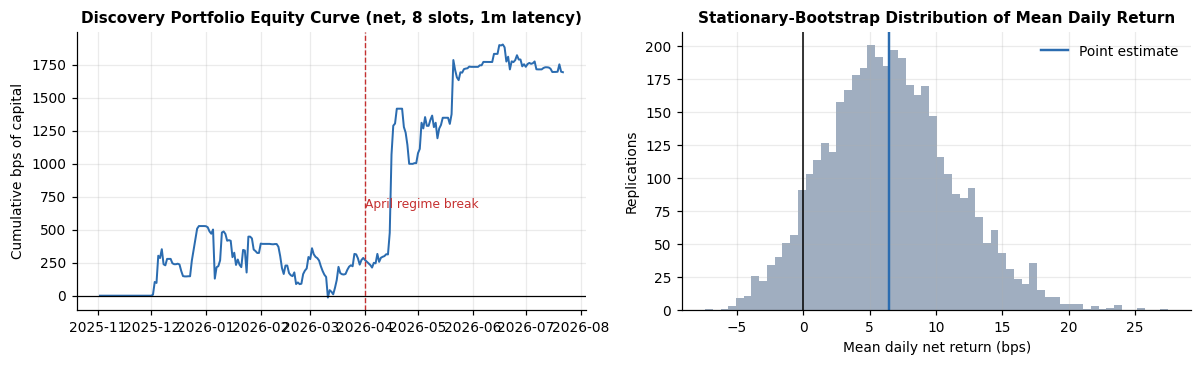

8.0% of bootstrap replications are at or below zero.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
eq = pd.Series(np.cumsum(DAILY)*1e4, index=FR.CAL)
axes[0].plot(eq.index, eq.values, lw=1.3, color="#2b6cb0")
axes[0].axhline(0, color="k", lw=.8); axes[0].axvline(SPLIT, color="#c53030", ls="--", lw=.9)
axes[0].set_ylabel("Cumulative bps of capital")
axes[0].set_title("Discovery Portfolio Equity Curve (net, 8 slots, 1m latency)")
axes[0].annotate("April regime break", xy=(SPLIT, eq.max()*.35), fontsize=8, color="#c53030")
draws = DAILY[FR.BOOT].mean(axis=1)*1e4
axes[1].hist(draws, bins=60, color="#a0aec0", edgecolor="none")
axes[1].axvline(0, color="k", lw=1)
axes[1].axvline(DAILY.mean()*1e4, color="#2b6cb0", lw=1.6, label="Point estimate")
axes[1].set_xlabel("Mean daily net return (bps)"); axes[1].set_ylabel("Replications")
axes[1].set_title("Stationary-Bootstrap Distribution of Mean Daily Return")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"{(draws <= 0).mean():.1%} of bootstrap replications are at or below zero.")

## 7. Wallet-identity placebo

The sharpest question a PM can ask about a wallet-based signal is whether it is really about
*those wallets*, or just about the kind of wallet — big, busy, frequent burst participants.

The test: within each score vintage, wallets are stratified into 20 propensity bins built from
observable characteristics only (log fill count, log notional, average clip, active days, prior
event-participation frequency, coin concentration, taker share, markout volatility). Scores are
then permuted **only among wallets in the same stratum**, and the entire signal — event quality,
CDF calibration, weights, portfolio — is rebuilt from scratch on each permutation. No outcome
data enters the matching.

If the real result sits inside the placebo distribution, the signal is archetype. If it sits
outside, exact wallet identity carries information that observable characteristics do not.

In [13]:
BR_ALL_S = BR_ALL.sort_values("ts")
rng = np.random.default_rng(20260726)
PLC = ST.strict_placebo(FR, FIRST, BR, D0, MB, MONTHS_ALL, FOLDS, BR_ALL_S, RL, rng)
ref_p = pd.read_csv(f"{BASE}/data/mechanism_out/d0_strict_identity_placebo.csv")
ref_p = ref_p[ref_p.score == "D0 mean-only"].set_index("channel")
rows = []
for chan, real, plc, incr, p, B in (
        ("Per trade", PLC["real_trade"], PLC["plc_trade"], PLC["incr_trade"], PLC["p_trade"], PLC["n_perm_trade"]),
        ("Daily estimand", PLC["real_daily"], PLC["plc_daily"], PLC["incr_daily"], PLC["p_daily"], PLC["n_perm_trade"]),
        ("Stateful portfolio", PLC["real_port"], PLC["plc_port"], PLC["incr_port"], PLC["p_port"], PLC["n_perm_port"])):
    rows.append(dict(channel=chan, real=real, placebo_mean=plc, identity_increment=incr,
                     permutations=B, min_attainable_p=1/(B+1), p_corrected=p))
PL = pd.DataFrame(rows)
print(PL.round(4).to_string(index=False))
print(f"""
The identity increment is what the exact wallet ranking adds on top of observable archetype.
p is the finite-permutation value (1 + #{{placebo >= real}}) / (B + 1); with {PLC['n_perm_trade']} permutations the
smallest attainable value is {1/(PLC['n_perm_trade']+1):.4f}, and with {PLC['n_perm_port']} portfolio permutations {1/(PLC['n_perm_port']+1):.4f}.
A permutation test cannot produce p = 0 and none is reported here.""")
PL.to_csv(f"{OUT}/identity_placebo.csv", index=False)

           channel    real  placebo_mean  identity_increment  permutations  min_attainable_p  p_corrected
         Per trade 35.8555       -2.8152             38.6708           150            0.0066       0.0066
    Daily estimand 19.5251       -1.1426             20.6678           150            0.0066       0.0265
Stateful portfolio  6.4346       -6.2849             12.7195            60            0.0164       0.0164

The identity increment is what the exact wallet ranking adds on top of observable archetype.
p is the finite-permutation value (1 + #{placebo >= real}) / (B + 1); with 150 permutations the
smallest attainable value is 0.0066, and with 60 portfolio permutations 0.0164.
A permutation test cannot produce p = 0 and none is reported here.


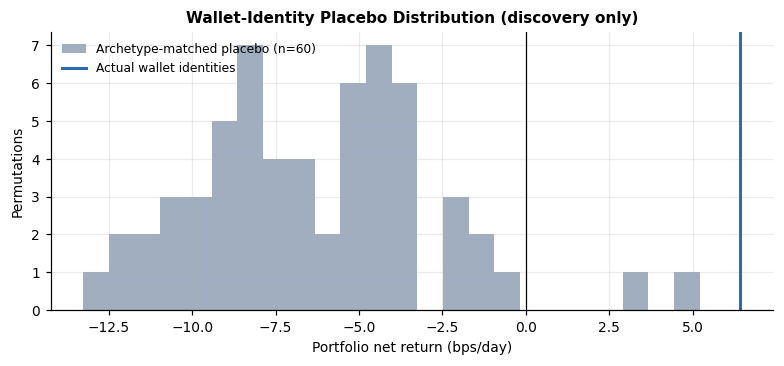

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.hist(PLC["draws_port"], bins=24, color="#a0aec0", edgecolor="none",
        label=f"Archetype-matched placebo (n={PLC['n_perm_port']})")
ax.axvline(PLC["real_port"], color="#2b6cb0", lw=2, label="Actual wallet identities")
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Portfolio net return (bps/day)"); ax.set_ylabel("Permutations")
ax.set_title("Wallet-Identity Placebo Distribution (discovery only)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 8. Robustness

Every panel is a diagnostic on the frozen strategy. Nothing here modifies the specification —
in particular the remove-best-events analysis is a fragility probe, not a variant.

In [15]:
r_trade = W*ENT[f"adj{H_PRIMARY}"].values
cost = np.abs(np.clip(W, -1, 1))*ENT.cost_bps.values/1e4
net_trade = r_trade - cost
BYC = pd.Series(r_trade, index=ENT.coin.values).groupby(level=0).sum()
tr_df = pd.DataFrame({"event_id": ENT.event_id.values, "pnl": r_trade})
j = BR.merge(tr_df, on="event_id")
j["sh"] = j.tk_buy_notl/j.groupby("event_id").tk_buy_notl.transform("sum")
BYW = j.assign(p=j.pnl*j.sh).groupby("address").p.sum()

# leave-largest-wallet-out: rebuild the router without that wallet's flow
top_wallet = BR.groupby("address").tk_buy_notl.sum().idxmax()
ent_ex = ST.route(FIRST, D0, BR[BR.address != top_wallet])
_, sim_ex = FR.simulate(ent_ex, np.nan_to_num(ent_ex.w_cal.values), label="")

order = np.argsort(-np.nan_to_num(r_trade))
def drop_best(k):
    keep = np.ones(len(r_trade), bool); keep[order[:k]] = False
    return FR.daily_vec(ENT.ts[keep], r_trade[keep]).mean()*1e4

long_leg, short_leg = W > 0, W < 0
ROB = pd.DataFrame([
    ("Pre-April 2026", f"{STAT['pre_apr_bps']:+.1f} bps/trade", ""),
    ("April-July 2026", f"{STAT['apr_jul_bps']:+.1f} bps/trade", "both regimes positive"),
    ("Latency 1m / 5m / 15m", f"{STAT['port_net']:+.2f} / {STAT['port_lat5']:+.2f} / "
     f"{STAT['port_lat15']:+.2f} bps/day", "degrades materially by 15m"),
    ("Leave-one-month-out (worst)", f"{STAT['loo_month_min']:+.1f} bps/day", "daily estimand"),
    ("Leave-one-coin-out (worst)", f"{STAT['loo_coin_min']:+.1f} bps/day", "daily estimand"),
    ("Leave-largest-wallet-out", f"{sim_ex['daily_bps']:+.2f} bps/day",
     f"vs {STAT['port_net']:+.2f}; that wallet is "
     f"{BR.groupby('address').tk_buy_notl.sum().max()/BR.tk_buy_notl.sum():.1%} of buy flow"),
    ("Top coin share of PnL", f"{BYC.max()/BYC.sum():.1%}", f"{ENT.coin.nunique()} coins traded"),
    ("Top wallet share of PnL", f"{BYW.max()/BYW.sum():.1%}", "flow-weighted attribution"),
    ("Capped event PnL (+/-500bps)", f"{FR.daily_vec(ENT.ts, np.clip(r_trade,-.05,.05)).mean()*1e4:+.2f} bps/day",
     f"vs {FR.daily_vec(ENT.ts, r_trade).mean()*1e4:+.2f} uncapped"),
    ("Remove best 1 / 5 / 10 events", f"{drop_best(1):+.2f} / {drop_best(5):+.2f} / "
     f"{drop_best(10):+.2f} bps/day", "diagnostic only — DOES NOT modify the strategy"),
    ("Long leg", f"{np.nanmean(r_trade[long_leg])*1e4:+.1f} bps/trade",
     f"n={int(long_leg.sum())}"),
    ("Short leg", f"{np.nanmean(r_trade[short_leg])*1e4:+.1f} bps/trade",
     f"n={int(short_leg.sum())}"),
    ("Scored-flow coverage", f"mean {ENT.coverage.mean():.1%}",
     f"10th pct {ENT.coverage.quantile(.1):.1%}"),
], columns=["Diagnostic", "Discovery result", "Note"])
print(ROB.to_string(index=False))
ROB.to_csv(f"{OUT}/robustness.csv", index=False)

                   Diagnostic                Discovery result                                           Note
               Pre-April 2026                 +19.5 bps/trade                                               
              April-July 2026                 +58.3 bps/trade                          both regimes positive
        Latency 1m / 5m / 15m   +6.43 / +4.52 / +1.33 bps/day                     degrades materially by 15m
  Leave-one-month-out (worst)                   +10.7 bps/day                                 daily estimand
   Leave-one-coin-out (worst)                   +15.3 bps/day                                 daily estimand
     Leave-largest-wallet-out                   +6.31 bps/day      vs +6.43; that wallet is 9.2% of buy flow
        Top coin share of PnL                           13.5%                               165 coins traded
      Top wallet share of PnL                            8.6%                      flow-weighted attribution
 Capped event PnL (

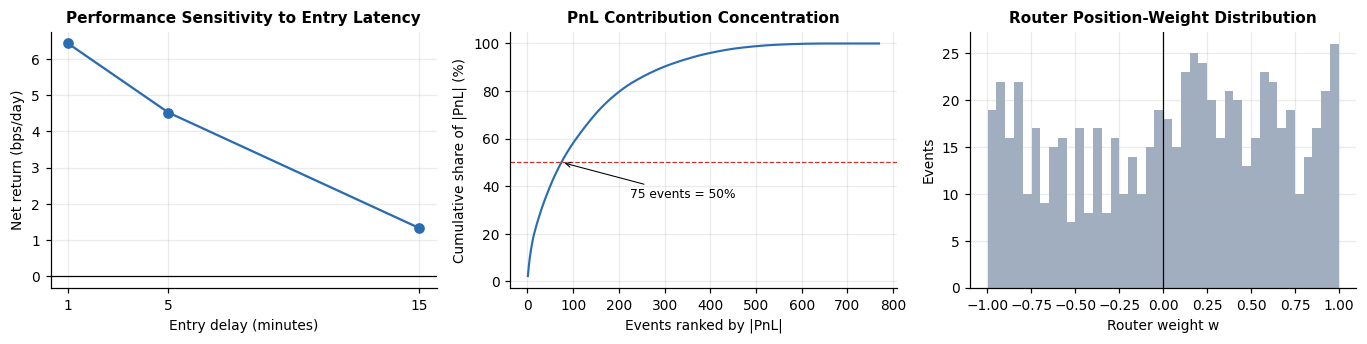

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
axes[0].plot([1,5,15], [STAT['port_net'], STAT['port_lat5'], STAT['port_lat15']],
             "o-", color="#2b6cb0")
axes[0].axhline(0, color="k", lw=.8); axes[0].set_xticks([1,5,15])
axes[0].set_xlabel("Entry delay (minutes)"); axes[0].set_ylabel("Net return (bps/day)")
axes[0].set_title("Performance Sensitivity to Entry Latency")

contrib = np.sort(np.abs(np.nan_to_num(r_trade)))[::-1]
axes[1].plot(np.arange(1, len(contrib)+1), np.cumsum(contrib)/contrib.sum()*100,
             color="#2b6cb0", lw=1.4)
axes[1].axhline(50, color="#c53030", ls="--", lw=.8)
axes[1].set_xlabel("Events ranked by |PnL|"); axes[1].set_ylabel("Cumulative share of |PnL| (%)")
axes[1].set_title("PnL Contribution Concentration")
k50 = int(np.searchsorted(np.cumsum(contrib)/contrib.sum(), .5)) + 1
axes[1].annotate(f"{k50} events = 50%", xy=(k50, 50), xytext=(k50*3, 35), fontsize=8,
                 arrowprops=dict(arrowstyle="->", lw=.7))

axes[2].hist(W[W != 0], bins=40, color="#a0aec0", edgecolor="none")
axes[2].axvline(0, color="k", lw=.8)
axes[2].set_xlabel("Router weight w"); axes[2].set_ylabel("Events")
axes[2].set_title("Router Position-Weight Distribution")
plt.tight_layout(); plt.show()

**Model-risk flag.** D0 and the earlier S0 t-stat score disagreed on direction for 87
discovery events, and S0 performed better on that subgroup (+94.3bps versus −94.0bps in their
respective directions). That is a post-selected subgroup with no significance attached, and it
does **not** justify adding an S0 override — doing so would reintroduce exactly the
specification tuning this phase closed. It remains a model-risk diagnostic to monitor
prospectively: if live disagreement events cluster and consistently favour S0, the score choice
should be revisited *after* the holdout, not before.

## 9. Capacity and execution

In [17]:
liq = ENT.groupby("lq_tercile").agg(n=("event_id","size"),
                                       med_liq=("liq_prev","median")).reset_index()
liq["tercile"] = liq.lq_tercile.map({0:"illiquid", 1:"mid", 2:"liquid"})
sig_per_day = len(ENT)/FR.NDAY
CAP = pd.DataFrame([
    ("Signals per day", f"{sig_per_day:.1f} first-signal episodes", "eligible events only"),
    ("Typical concurrent positions", f"{occ[occ>0].mean():.2f} (max {int(occ.max())} of 8)",
     "slot limit rarely binds"),
    ("Slot rejections in discovery", f"{SIM['skipped']}", "signals dropped for want of a slot"),
    ("Turnover", f"{STAT['turnover']:.2f} x capital/day", "both sides, |w|-scaled"),
    ("Required entry latency", "<= 1 minute for the frozen result",
     f"5m costs {STAT['port_net']-STAT['port_lat5']:.1f}, 15m costs {STAT['port_net']-STAT['port_lat15']:.1f} bps/day"),
    ("Execution style", "Taker required", "signal decays within minutes; maker fills are not modelled"),
    ("Spread assumption", "20 / 8 / 4 bps half-spread by liquidity tercile",
     "MODELLED, not measured at event times"),
    ("Events by liquidity tercile", " / ".join(f"{r.tercile} {r.n}" for r in liq.itertuples()),
     "median prior-day volume per tercile in the appendix"),
], columns=["Item", "Estimate", "Basis"])
print(CAP.to_string(index=False))
print("""
CAPACITY IS NOT ESTIMATED HERE, and the missing calculation is named rather than guessed:
sizing capacity requires order-book depth and realized spread at the event timestamps, which
this research never pulled. What exists is prior-day traded volume per coin, which bounds
nothing tightly enough to quote a dollar figure. The shadow run is the correct place to measure
it: log top-of-book depth and realized fill slippage at every signal, then size from observed
fills rather than from a modelled half-spread.

The spread assumption is the single largest cost-model risk. The 20/8/4 bps terciles are
unconditional averages applied to burst moments, when thin perpetuals are plausibly wider. If
the illiquid tercile is really ~30bps, roughly 2-3 bps/day comes off the base case, which is
most of it.""")

                        Item                                        Estimate                                                      Basis
             Signals per day                       2.9 first-signal episodes                                       eligible events only
Typical concurrent positions                               1.38 (max 7 of 8)                                    slot limit rarely binds
Slot rejections in discovery                                               0                         signals dropped for want of a slot
                    Turnover                              0.32 x capital/day                                     both sides, |w|-scaled
      Required entry latency               <= 1 minute for the frozen result                        5m costs 1.9, 15m costs 5.1 bps/day
             Execution style                                  Taker required signal decays within minutes; maker fills are not modelled
           Spread assumption 20 / 8 / 4 bps half

## 10. Risk register

In [18]:
RISK = pd.DataFrame([
 ("Discovery overfitting",
  "The sample was iterated on heavily across seven notebooks",
  "Identity placebo p=0.0066; specification frozen and hashed; failed variants documented",
  "Holdout is the test; no further tuning permitted", "No — the holdout is untouched"),
 ("Positive-skew dependence",
  "Median trade loses; returns come from a right tail",
  "Medians negative in all five quintiles; removing best 10 events materially reduces the result",
  "Track realized skew and hit rate vs discovery", "No"),
 ("Event-tail concentration",
  "A small number of events drive half the |PnL|",
  f"{k50} of {int((W!=0).sum())} events = 50% of |PnL|; top coin {BYC.max()/BYC.sum():.0%}",
  "Per-event and per-coin contribution monitoring", "No"),
 ("Latency decay",
  "Edge lives in the first minutes after the signal",
  "15m entry roughly halves the daily return",
  "Log data-availability and entry timestamps on every signal", "No — but invalidates live economics if unmet"),
 ("Cost-model error",
  "Half-spreads are modelled, not measured at event times",
  "20/8/4 bps assumption; illiquid tercile is a third of events",
  "Record realized slippage per fill in shadow", "No — but could void the net result"),
 ("Wallet regime drift",
  "The scored population turns over; a vintage may not describe the next month",
  "Rank stability ~0.75 month to month across vintages",
  "Vintage rank-correlation and cohort turnover per fold", "No"),
 ("Wallet-score staleness",
  "Scores are monthly; a wallet's behaviour can change intra-month",
  "Not tested — monthly vintages are frozen",
  "Score age at signal time; flag if pipeline lags", "No"),
 ("Identity or address change",
  "Wallets can migrate addresses, breaking the identity link the placebo validates",
  "Not tested in discovery",
  "New-address share of event flow; coverage drift", "No"),
 ("Venue microstructure change",
  "Fee tiers, tick sizes or listing rules can move the cost base",
  "Costs frozen at 4.5bps fee + 2bps slip + tercile spread",
  "Reconcile actual fees monthly", "No"),
 ("BTC-hedge basis risk",
  "Beta is frozen at 1 for every coin and regime",
  "Beta=1 used throughout; per-coin rolling beta not used in the final spec",
  "Track hedge slippage and residual market exposure", "No"),
 ("Burst-detector dependence",
  "The whole universe is conditioned on a detector whose code is not a standalone module",
  "Parameters frozen (25x, $3k, >=8 wallets); event table is a frozen artifact",
  "Re-implement and reconcile against the artifact BEFORE shadow", "YES if the live detector differs"),
 ("CDF calibration drift",
  "The router's zero point is the trailing event-quality distribution",
  "Expanding window, 100-event minimum; drift left some asymmetry across scores",
  "Track realized u distribution vs uniform", "No"),
 ("Low scored-flow coverage",
  "Events where few buyers are scored give a noisier quality estimate",
  f"mean coverage {ENT.coverage.mean():.0%}, 10th pct {ENT.coverage.quantile(.1):.0%}",
  "Coverage per signal; alert below the discovery 10th percentile", "No"),
 ("Concurrent-position crowding",
  "Simultaneous signals concentrate risk in one direction",
  f"average {occ[occ>0].mean():.1f} of 8 slots used; {SIM['skipped']} slot rejections",
  "Net exposure and slot utilisation", "No"),
 ("Operational data failure",
  "Missing fills or late price data silently changes the signal",
  "Discovery had 16 transient S3 failures, all rebuilt",
  "Missing-data rate, schema checks, reconciliation failures", "YES if signals are computed on incomplete data"),
], columns=["Risk", "Why it matters", "Current evidence", "Live monitoring", "Invalidates holdout?"])
pd.set_option("display.max_colwidth", 52)
print(RISK.to_string(index=False))
RISK.to_csv(f"{OUT}/risk_register.csv", index=False)

                        Risk                                                                        Why it matters                                                                              Current evidence                                                Live monitoring                           Invalidates holdout?
       Discovery overfitting                             The sample was iterated on heavily across seven notebooks        Identity placebo p=0.0066; specification frozen and hashed; failed variants documented               Holdout is the test; no further tuning permitted                  No — the holdout is untouched
    Positive-skew dependence                                    Median trade loses; returns come from a right tail Medians negative in all five quintiles; removing best 10 events materially reduces the result                  Track realized skew and hit rate vs discovery                                             No
    Event-tail concentration               

## 11. Frozen holdout plan

* **Holdout begins** 2026-07-23 (already accruing, never inspected).
* **Formal test requires >= 300 eligible first-signal episodes.** This may not be silently
  lowered.
* **Checkpoints, frozen in advance:** 2026-09-15, 2026-10-15, 2026-11-15, 2026-12-15, monthly
  thereafter if needed. September 15 is an *operational* checkpoint, not automatically the
  evaluation date.
* **Formal evaluation occurs at the first checkpoint on or after 300 episodes have accrued.**

At every pre-formal checkpoint only these may be inspected: episode counts, pipeline health,
schema integrity, latency, missing-data rates, score freshness, coverage. The following may not
be inspected in any form: cumulative PnL, mean return, Sharpe, hit rate, trade-level outcomes,
long/short performance, coin attribution, month attribution.

**Primary test**

```
H0: mean net calendar-day portfolio return <= 0
    inactive days included as zero
    the exact frozen stateful simulator (routing_lib.py)
    stationary bootstrap, mean geometric block length 5 days
    one-sided 5%
    no alternative bootstrap settings after observing the holdout
```

Result is classified **Passed**, **Rejected**, or **Inconclusive**. The evaluation runs once, in
notebook 09, which is locked and unexecuted.

## 12. Shadow-trading plan

`shadow_runner.py` writes one row per signal to a locked log. Fields:

| Group | Fields |
|---|---|
| Timing | signal timestamp, data-availability timestamp, entry timestamp, exit timestamp |
| Signal | score vintage, score age, event quality, CDF percentile `u`, position weight `w`, scored-flow coverage, buyer count |
| Execution | simulated entry price, hedge entry, cost estimate, slot state, skip reason |
| Outcome | gross PnL, net PnL — **written to the locked log, not surfaced** |
| Health | missing-data flags, latency, reconciliation status, schema version |

Operational dashboards may show signal counts, missing-data rates, latency, score freshness,
position-limit errors and reconciliation failures. **Before formal evaluation, no dashboard may
show strategy profitability in any form.** The shadow runner enforces this by writing outcome
columns only to `data/holdout_locked/`, which the health dashboard does not read.

## 13. PM decision page

### Why continue

* Economically coherent router: the same burst is routed long or short by who is buying, which
  is a statement about participants rather than a price pattern.
* Event-quality means are monotonic across fixed quintiles, with a Q5−Q1 spread of roughly
  220bps and a regression slope whose corrected bootstrap interval excludes zero.
* Exact wallet identity survives a strict archetype-matched placebo — the signal is not a
  restatement of wallet size, activity or burst-participation frequency.
* The discovery portfolio is positive in both observed regimes, including the post-April period
  in which every earlier version of this research died.
* The simpler mean-only score performs as well as the standardized t-stat, and the
  standardization term adds no stable incremental information.
* The specification is fully executable: every input is available at signal time, and the
  implementation is frozen and hashed.

### Why remain skeptical

* The discovery portfolio confidence interval includes zero. Nothing here is statistically
  established.
* Results depend on a right tail; the median trade loses and a small number of events drive
  half the PnL.
* Latency degrades performance materially by 15 minutes, so the live result depends on
  execution quality that has not yet been demonstrated.
* The strategy remains conditioned on the original burst universe, and the detector's
  implementing code is a frozen artifact rather than a module.
* The mechanism is observational: the score does not predict wallets' own forward returns, and
  why it orders event outcomes is unexplained.
* The discovery sample was iterated on extensively across seven notebooks before this candidate
  emerged.

### Required next decision

> Run the locked holdout and shadow strategy. Do not allocate risk unless the primary holdout
> criterion is met and execution logs show the assumed latency and costs are realistic.

## Appendix — statistical and implementation detail

In [19]:
APX = pd.DataFrame([
    ("Bootstrap", "Stationary, geometric blocks, mean length 5 calendar days, 4000 replications; "
                  "day multiplicity preserved in event regressions"),
    ("Placebo", f"{PLC['n_perm_trade']} permutations within 20 propensity strata per vintage; "
                f"{PLC['n_perm_port']} full portfolio rebuilds; p = (1+#{{plc>=real}})/(B+1)"),
    ("Episode rule", "Anchored 8h: first event of a coin opens [t, t+8h); next event after that "
                     "span opens the next episode"),
    ("Calibration burn-in", f"{int(np.isnan(ENT.w_cal.values).sum())} events weightless before "
                            f"{ST.MIN_HIST} prior events exist"),
    ("Cost per trade", f"mean {ENT.cost_bps.mean():.1f} bps of position notional "
                       "(53/29/21 by liquidity tercile)"),
    ("Outcome", "coin minute-close return minus BTC over the same window (beta = 1)"),
    ("Wallet-level predictiveness", "Spearman 0.006-0.019 across all five wallet-level targets — "
                                    "the score does not rank traders"),
    ("Score reconstruction", "reproduces the historical cohort mapping exactly at the 100-fill "
                             "threshold"),
    ("Known gap", "burst detector implementing code is not a standalone module; live "
                  "re-implementation must reconcile against data/burst_events.parquet"),
], columns=["Item", "Detail"])
print(APX.to_string(index=False))

FINAL = pd.DataFrame([dict(strategy="wallet_markout_router_v2",
    discovery_start=str(ENT.ts.min().date()), discovery_end=str(ENT.ts.max().date()),
    episodes=len(ENT), traded=int((W != 0).sum()),
    port_net_bps_day=STAT["port_net"], port_lo=STAT["port_lo"], port_hi=STAT["port_hi"],
    sharpe=STAT["sharpe"], max_dd_bps=STAT["max_dd"],
    beta_bps=REG["beta_bps"], beta_lo=REG["lo"], beta_hi=REG["hi"],
    placebo_p_trade=PLC["p_trade"], placebo_p_port=PLC["p_port"],
    identity_incr_trade=PLC["incr_trade"], identity_incr_port=PLC["incr_port"],
    status="candidate — awaiting holdout")])
FINAL.to_csv(f"{OUT}/pm_summary.csv", index=False)
print(f"""
================================ STATUS ================================
wallet_markout_router_v2 is a DISCOVERY-SELECTED CANDIDATE.
Discovery portfolio {STAT['port_net']:+.2f} bps/day, CI [{STAT['port_lo']:+.2f}, {STAT['port_hi']:+.2f}] — includes zero.
Not proven, not established, not ready for production.
Next legitimate step: shadow execution + one holdout test under the frozen specification.
========================================================================""")

                       Item                                                                                                                               Detail
                  Bootstrap        Stationary, geometric blocks, mean length 5 calendar days, 4000 replications; day multiplicity preserved in event regressions
                    Placebo                     150 permutations within 20 propensity strata per vintage; 60 full portfolio rebuilds; p = (1+#{plc>=real})/(B+1)
               Episode rule                                Anchored 8h: first event of a coin opens [t, t+8h); next event after that span opens the next episode
        Calibration burn-in                                                                                  100 events weightless before 100 prior events exist
             Cost per trade                                                                   mean 34.8 bps of position notional (53/29/21 by liquidity tercile)
                    Outcome       